In [1]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/clean_energy.csv")
df["Datetime"] = pd.to_datetime(df["Datetime"])
df.set_index("Datetime", inplace=True)

In [3]:
df["Year"] = df.index.year
df["Month"] = df.index.month
df["Day"] = df.index.day
df["Hour"] = df.index.hour
df["DayOfWeek"] = df.index.dayofweek

df["Lag_1"] = df["PJME_MW"].shift(1)
df["Lag_24"] = df["PJME_MW"].shift(24)
df["Lag_168"] = df["PJME_MW"].shift(168)

df["Rolling24"] = df["PJME_MW"].rolling(24).mean()
df["Rolling168"] = df["PJME_MW"].rolling(168).mean()

df = df.dropna()

In [4]:
model = joblib.load("../models/xgboost.pkl")

In [5]:
features = [
    "Year",
    "Month",
    "Day",
    "Hour",
    "DayOfWeek",
    "Lag_1",
    "Lag_24",
    "Lag_168",
    "Rolling24",
    "Rolling168"
]

X = df[features]

In [6]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

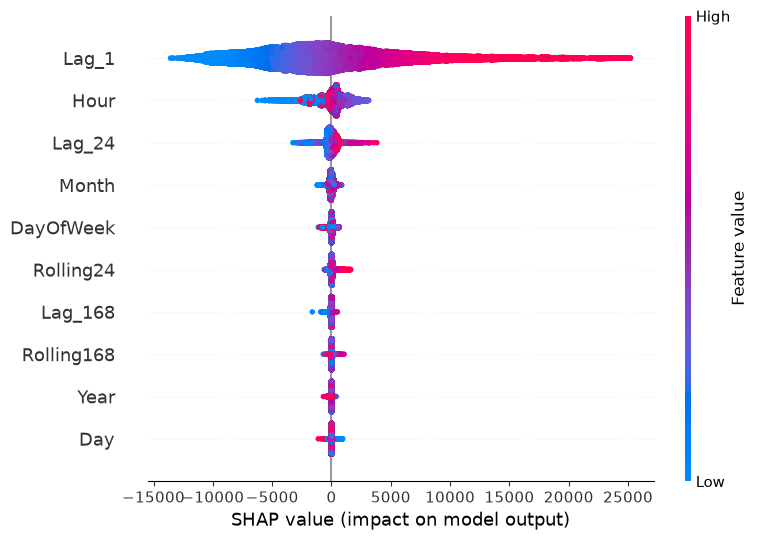

In [7]:
shap.summary_plot(shap_values, X)

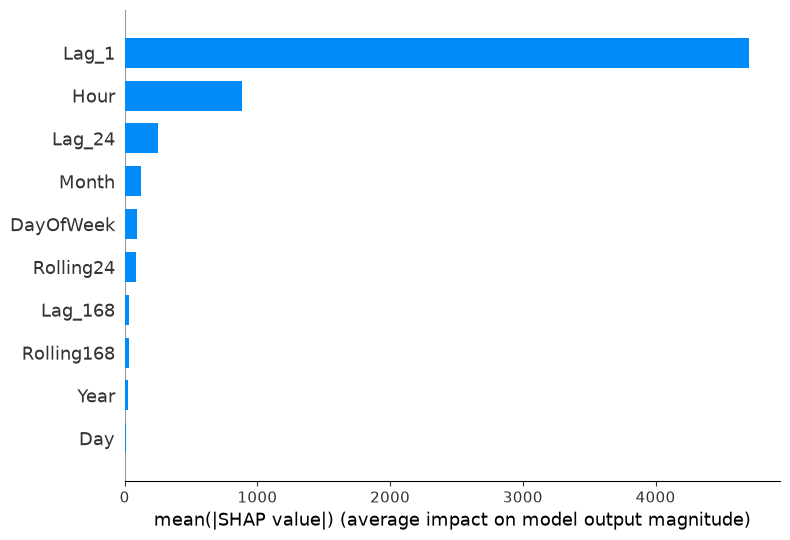

In [8]:
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar"
)

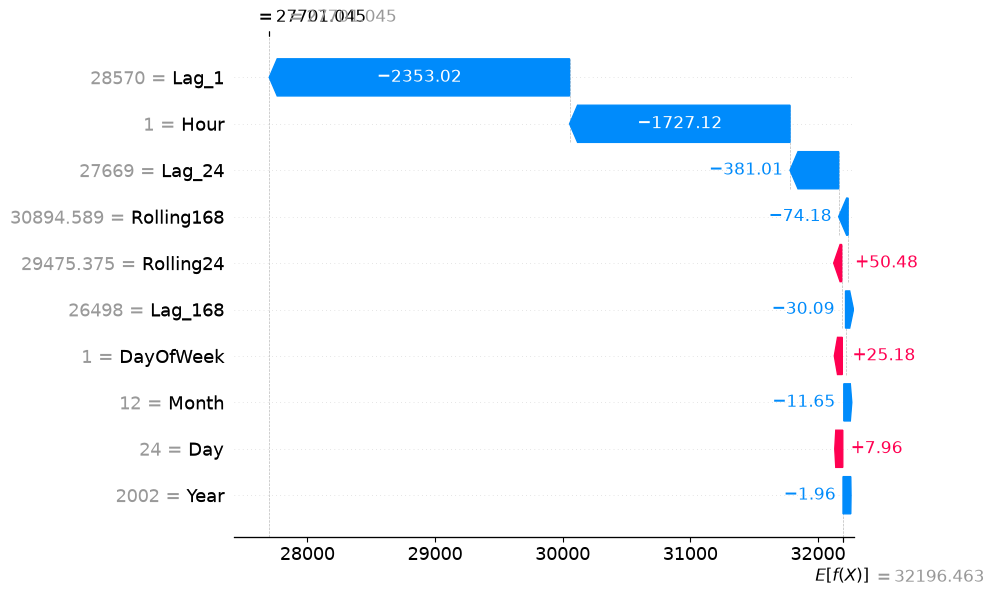

In [9]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X.iloc[0],
        feature_names=X.columns
    )
)